In [1]:
from azure.storage.blob import BlobServiceClient, BlobClient, ContainerClient
import os
from dotenv import load_dotenv
import parselmouth
import librosa
import speechpy
import scipy.io.wavfile as wav
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import csv
import io
import soundfile as sf 

pd.set_option('display.max_columns', None)

In [2]:
load_dotenv()
connect_str = os.getenv('AZURE_STORAGE_CONNECTION_STRING')

if not connect_str:
    connect_str = 'Your_Connection_String'

blob_service_client = BlobServiceClient.from_connection_string(connect_str)

# Data Prep - DO NOT RUN

## Feature creation

In [3]:
audio_path = r"C:\Users\zandr\OneDrive\Desktop\NUS Work\BT4103\faith-speechsdk\speechsdk\data\primock\day1_consultation01_doctor.wav"
snd = parselmouth.Sound(audio_path)

In [4]:
# average intensity -- average loudness of sound 
intensity = snd.get_intensity()

# total energy -- sum of squares of the amplitude values of the signal. identifies segments with high or low energy 
energy = snd.get_energy()

# total power -- similar to energy, but typically normalised over time, providing a measure of the signal's strength
power = snd.get_power()

# how much power reaches the listener's location, accounting for factors like distance.
power_in_air = snd.get_power_in_air()

# average power - for loudness estimation, variability in loudness throughout the audio
rms = snd.get_rms()

# total number of audio samples in the file. a sample = discrete measurement of the audio signal's amplitude at a specific point in time
# sampling is the process of measuring the amplitude (volume) at regular time intercals
# number of samples taken per second is determined by the sampling rate / freq
num_samples = snd.get_number_of_samples()

# sampling freq = numberof samples of the audio signals taken per second 
sampling_frequency = snd.get_sampling_frequency()

# time interval between consecutive samples
sampling_period = snd.get_sampling_period()



In [5]:
# mfcc - set of features that represent the short term power spectrum of a sound.
# mel scale is a perceptual scale that spaces frequencies more closely at lower ranges and more widly at higher ranges, aligning with how humans perceive pitch.
# mfccs provide a concise representation of the spectral properties of audio, reducing the dimensionality of data while retaining essential info

fs, signal = wav.read(audio_path)

# Compute MFCCs
mfcc = speechpy.feature.mfcc(signal, fs, num_cepstral=13, frame_length=0.025, frame_stride=0.01)

mfcc_mean = float(mfcc.mean())
mfcc_min = float(mfcc.min())
mfcc_max = float(mfcc.max())

In [9]:
snd_formant = snd.to_formant_burg()
times = np.linspace(0, snd.duration, num=500)

# Initialize lists to store formant values

# Formants are the resonant frequencies of the vocal tract that define the characteristic sound of speech. They correspond to peaks in the frequency spectrum of a sound and are critical for distinguishing different vowel sounds. The first two formants, F1 and F2, are particularly important for identifying vowel qualities.
F1 = []
F2 = []
F3 = []

for t in times:
    f1 = snd_formant.get_value_at_time(1, t)  # First Formant
    f2 = snd_formant.get_value_at_time(2, t)  # Second Formant
    f3 = snd_formant.get_value_at_time(3, t)  # Third Formant
    
    # Only append if formant frequency is valid (non-zero)
    if f1 != 0 and not np.isnan(f1):
        F1.append(f1)
    if f2 != 0 and not np.isnan(f1):
        F2.append(f2)
    if f3 != 0 and not np.isnan(f1):
        F3.append(f3)


In [10]:
f1_mean = float(np.mean(F1))
f1_min = float(np.min(F1))
f1_max = float(np.max(F1))

f2_mean = float(np.mean(F2))
f2_min = float(np.min(F2))
f2_max = float(np.max(F2))

f3_mean = float(np.mean(F3))
f3_min = float(np.min(F3))
f3_max = float(np.max(F3))

In [ ]:
import csv
# append as new rows to a csv
new_row = [intensity, energy, power, power_in_air, rms, num_samples, sampling_frequency, sampling_period, mfcc_mean, mfcc_min, mfcc_max, f1_mean, f1_min, f1_max, f2_mean, f2_min, f2_max, f3_mean, f3_min, f3_max]

with open('files/speech_analysis.csv', mode='a', newline='') as file:
    writer = csv.writer(file)
    writer.writerows(new_row)

## Processing all audio files

In [32]:
def create_features(audio_path):
    snd = parselmouth.Sound(audio_path)

    intensity = snd.get_intensity()
    energy = snd.get_energy()
    power = snd.get_power()
    power_in_air = snd.get_power_in_air()
    rms = snd.get_rms()
    num_samples = snd.get_number_of_samples()
    sampling_frequency = snd.get_sampling_frequency()
    sampling_period = snd.get_sampling_period()

    fs, signal = wav.read(audio_path)

    # Compute MFCCs
    mfcc = speechpy.feature.mfcc(signal, fs, num_cepstral=13, frame_length=0.025, frame_stride=0.01)

    mfcc_mean = float(mfcc.mean())
    mfcc_min = float(mfcc.min())
    mfcc_max = float(mfcc.max())

    snd_formant = snd.to_formant_burg()
    times = np.linspace(0, snd.duration, num=500)

    F1 = []
    F2 = []
    F3 = []

    for t in times:
        f1 = snd_formant.get_value_at_time(1, t)  # First Formant
        f2 = snd_formant.get_value_at_time(2, t)  # Second Formant
        f3 = snd_formant.get_value_at_time(3, t)  # Third Formant
        
        # Only append if formant frequency is valid (non-zero)
        if f1 != 0 and not np.isnan(f1):
            F1.append(f1)
        if f2 != 0 and not np.isnan(f1):
            F2.append(f2)
        if f3 != 0 and not np.isnan(f1):
            F3.append(f3)

    f1_mean = float(np.mean(F1))
    f1_min = float(np.min(F1))
    f1_max = float(np.max(F1))

    f2_mean = float(np.mean(F2))
    f2_min = float(np.min(F2))
    f2_max = float(np.max(F2))

    f3_mean = float(np.mean(F3))
    f3_min = float(np.min(F3))
    f3_max = float(np.max(F3))

    new_row = [intensity, energy, power, power_in_air, rms, num_samples, sampling_frequency, sampling_period, mfcc_mean, mfcc_min, mfcc_max, f1_mean, f1_min, f1_max, f2_mean, f2_min, f2_max, f3_mean, f3_min, f3_max]
    new_row = [round(x, 4) for x in new_row]
    return new_row

create_features(audio_path)

[73.94,
 4.54,
 0.01,
 0.0,
 0.1,
 7326720,
 16000.0,
 0.0,
 1.66,
 -25.84,
 30.91,
 865.6,
 209.64,
 2491.84,
 1942.25,
 415.97,
 3888.82,
 3099.88,
 1297.65,
 4529.46]

In [33]:
def process_blob(container_name, blob_name):
    try:
        # Get a BlobClient for the specific blob
        blob_client = blob_service_client.get_blob_client(container=container_name, blob=blob_name)
        # Download the blob content to memory (streaming)
        download_stream = blob_client.download_blob()
        # Read the blob data (this is in bytes)
        blob_data = download_stream.readall()

        # Convert the blob_data (bytes) into an audio format readable by librosa, parselmouth, etc.
        audio_buffer = io.BytesIO(blob_data)

        # Verify that the file format is WAV by checking headers
        # Read audio using scipy wavfile
        fs, signal = wav.read(audio_buffer)  # Reading the audio as signal and sampling rate

        # -------------------------
        # Process with Parselmouth
        # -------------------------
        snd = parselmouth.Sound(signal, fs)  # Pass signal and sample rate to Parselmouth

        # Extract intensity, energy, power, etc. from Parselmouth
        intensity = snd.get_intensity()
        energy = snd.get_energy()
        power = snd.get_power()
        power_in_air = snd.get_power_in_air()
        rms = snd.get_rms()
        num_samples = snd.get_number_of_samples()
        sampling_frequency = snd.get_sampling_frequency()
        sampling_period = snd.get_sampling_period()

        # -------------------------
        # Process with SpeechPy
        # -------------------------
        # Pre-emphasis and MFCC calculation using SpeechPy
        mfcc = speechpy.feature.mfcc(signal, fs, num_cepstral=13, frame_length=0.025, frame_stride=0.01)

        # Aggregate MFCC features
        mfcc_mean = float(mfcc.mean())
        mfcc_min = float(mfcc.min())
        mfcc_max = float(mfcc.max())

        # -------------------------
        # Extract Formants from Parselmouth
        # -------------------------
        snd_formant = snd.to_formant_burg()
        times = np.linspace(0, snd.duration, num=500)

        F1, F2, F3 = [], [], []

        for t in times:
            f1 = snd_formant.get_value_at_time(1, t)  # First Formant
            f2 = snd_formant.get_value_at_time(2, t)  # Second Formant
            f3 = snd_formant.get_value_at_time(3, t)  # Third Formant

            # Only append if formant frequency is valid (non-zero and non-NaN)
            if f1 != 0 and not np.isnan(f1):
                F1.append(f1)
            if f2 != 0 and not np.isnan(f2):
                F2.append(f2)
            if f3 != 0 and not np.isnan(f3):
                F3.append(f3)

        f1_mean = float(np.mean(F1)) if F1 else 0
        f1_min = float(np.min(F1)) if F1 else 0
        f1_max = float(np.max(F1)) if F1 else 0

        f2_mean = float(np.mean(F2)) if F2 else 0
        f2_min = float(np.min(F2)) if F2 else 0
        f2_max = float(np.max(F2)) if F2 else 0

        f3_mean = float(np.mean(F3)) if F3 else 0
        f3_min = float(np.min(F3)) if F3 else 0
        f3_max = float(np.max(F3)) if F3 else 0

        # Create a row of features for this audio file
        new_row = [
            intensity, energy, power, power_in_air, rms, num_samples, sampling_frequency, sampling_period,
            mfcc_mean, mfcc_min, mfcc_max,
            f1_mean, f1_min, f1_max, f2_mean, f2_min, f2_max, f3_mean, f3_min, f3_max
        ]
        new_row = [round(x, 4) for x in new_row]

        # Append to the CSV file
        with open('files/speech_analysis.csv', mode='a', newline='') as file:
            writer = csv.writer(file)
            writer.writerow(new_row)  # write one row at a time
        print(f"Appended blob: {blob_name}")

    except Exception as e:
        print(f"Error processing blob {blob_name}: {str(e)}")

# List all blobs and process them without downloading
def list_and_process_blobs(container_name):
    container_client = blob_service_client.get_container_client(container_name)

    print(f"Listing and processing blobs in container: {container_name}")
    blob_list = container_client.list_blobs()
    for blob in blob_list:
        print(f" - Found blob: {blob.name}")
        process_blob(container_name, blob.name)

# Call the function to list and process blobs
list_and_process_blobs('primock57audio')


Listing and processing blobs in container: primock57audio
 - Found blob: day1_consultation01_doctor.wav
Appended blob: day1_consultation01_doctor.wav
 - Found blob: day1_consultation01_patient.wav
Appended blob: day1_consultation01_patient.wav
 - Found blob: day1_consultation02_doctor.wav
Appended blob: day1_consultation02_doctor.wav
 - Found blob: day1_consultation02_patient.wav
Appended blob: day1_consultation02_patient.wav
 - Found blob: day1_consultation03_doctor.wav
Appended blob: day1_consultation03_doctor.wav
 - Found blob: day1_consultation03_patient.wav
Appended blob: day1_consultation03_patient.wav
 - Found blob: day1_consultation04_doctor.wav
Appended blob: day1_consultation04_doctor.wav
 - Found blob: day1_consultation04_patient.wav
Appended blob: day1_consultation04_patient.wav
 - Found blob: day1_consultation05_doctor.wav
Appended blob: day1_consultation05_doctor.wav
 - Found blob: day1_consultation05_patient.wav
Appended blob: day1_consultation05_patient.wav
 - Found blo

# Checkbox feature analysis

In [2]:
primock = pd.read_csv(r'C:\Users\zandr\OneDrive\Desktop\NUS Work\BT4103\faith-speechsdk\speechsdk\data\eval\primock57_speechsdk_realtime.csv')
print(primock.shape)
primock = primock.rename(columns={'id': 'speaker'})
primock.head(3)

(114, 7)


,speaker,transcription,reference,mer,wil,wip,wer
0,day1_consultation01_doctor,Hello. Hi. Yeah. OK. Hello. Good morning. How ...,"Hello? Hi. Um, should we start? Yeah, okay. He...",0.204522,0.289805,0.710195,0.209253
1,day1_consultation01_patient,"Hello, how are you? Hi, I just had some diarrh...","Hello, how are you? Oh hey, um, I've just had ...",0.200772,0.260102,0.739898,0.204724
2,day1_consultation02_doctor,"Hello. Yes, I think it's a bit better. It's a ...",Hello? Uh uh yes. I think. It's a bit better. ...,0.140334,0.180209,0.819791,0.143143


In [3]:
her = pd.read_csv('files/healthcare_entity_information.csv')
her = her.drop(['Unnamed: 0'], axis=1)
print(her.shape)
her.head(3)

(5732, 5)


,category,confidence_score,data_source,text,speaker
0,Time,0.80,24,morning,day1_consultation01_doctor
1,SymptomOrSign,0.98,79,diarrhoea,day1_consultation01_doctor
2,SymptomOrSign,0.98,110,diarrhea,day1_consultation01_doctor


In [4]:
# join the dfs
merged = pd.merge(her, primock[['speaker', 'mer', 'wil', 'wip', 'wer']], on='speaker', how='left')
merged['role'] = np.where(merged['speaker'].str.contains('doctor'), 'doctor', 'patient')
print(merged.shape)
merged.head(3)

(5732, 10)


,category,confidence_score,data_source,text,speaker,mer,wil,wip,wer,role
0,Time,0.80,24,morning,day1_consultation01_doctor,0.204522,0.289805,0.710195,0.209253,doctor
1,SymptomOrSign,0.98,79,diarrhoea,day1_consultation01_doctor,0.204522,0.289805,0.710195,0.209253,doctor
2,SymptomOrSign,0.98,110,diarrhea,day1_consultation01_doctor,0.204522,0.289805,0.710195,0.209253,doctor


In [5]:
# analyse doctor and patient separately

doctor = merged[merged['role'] == 'doctor'] 
print(doctor.shape)
patient = merged[merged['role'] == 'patient'] 
print(patient.shape)

(4193, 10)
(1539, 10)


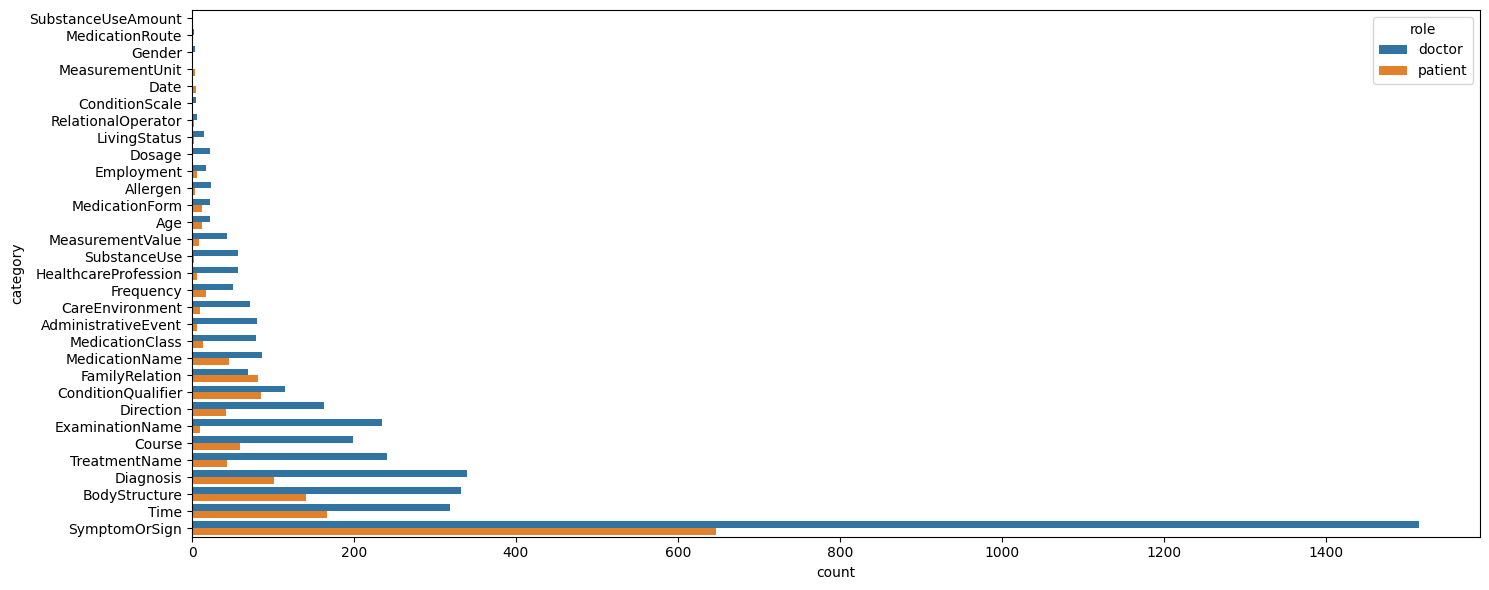

In [10]:
category_order = merged['category'].value_counts(ascending=True).index

# Create the countplot with categories ordered by their counts
fig, ax = plt.subplots(figsize=(15, 6))

sns.countplot(data=merged, y='category', hue='role', ax=ax, order=category_order)

plt.tight_layout()
plt.show()

Checkbox options to include:
- SymptomOrSign
- Diagnosis
- BodyStructure
- Time
- TreatmentName

<Axes: xlabel='confidence_score'>

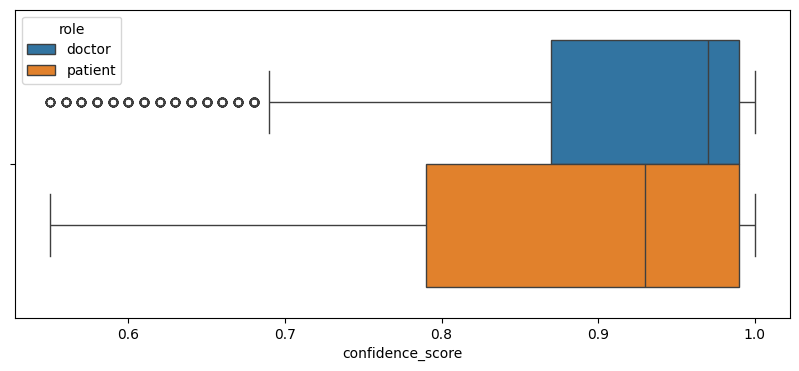

In [13]:
plt.figure(figsize=(10, 4))
sns.boxplot(data=merged, x='confidence_score', hue='role')

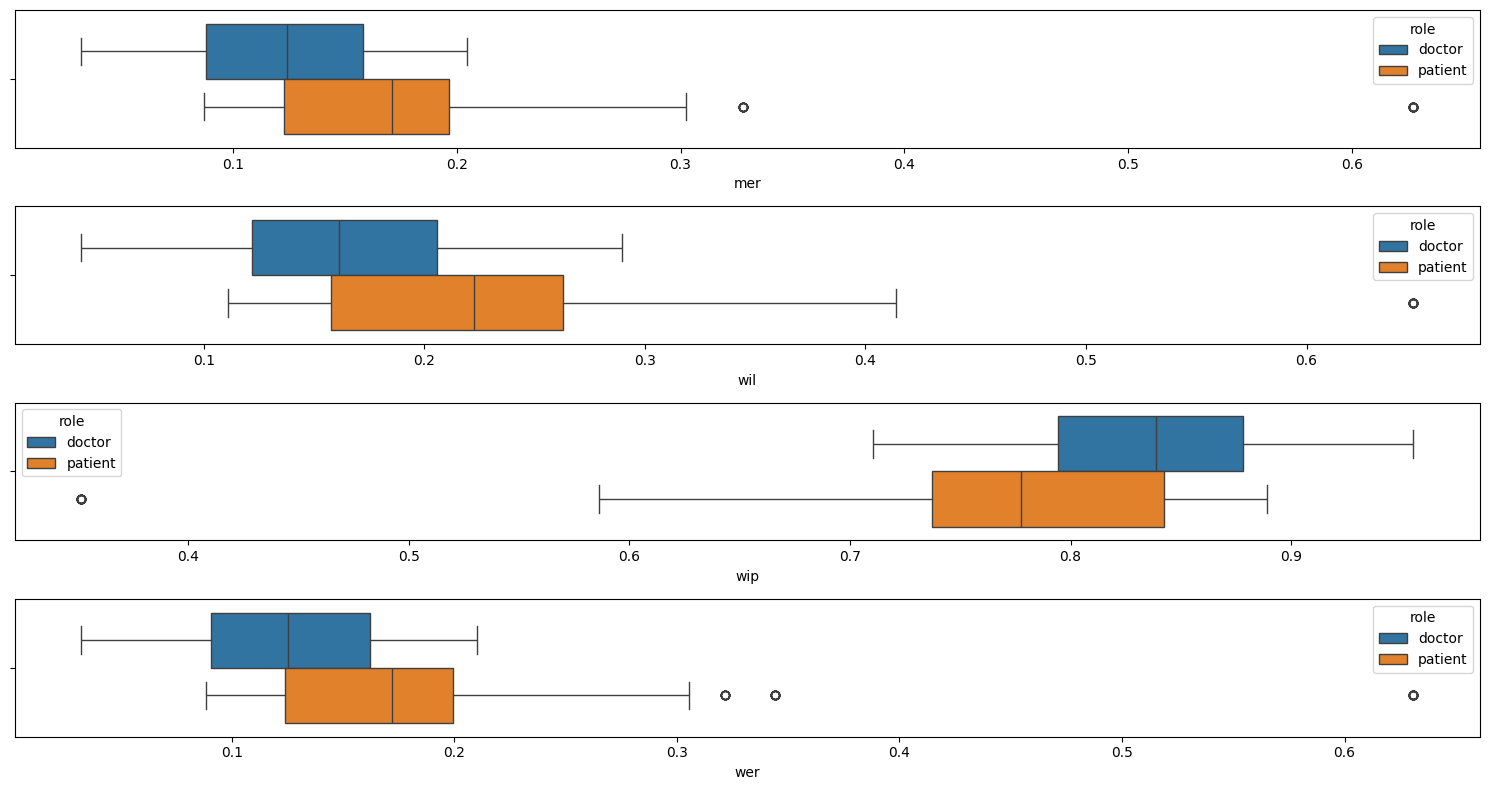

In [14]:
fig, axs = plt.subplots(4, 1, figsize=(15, 8))

sns.boxplot(data=merged, x='mer', hue='role', ax=axs[0])
sns.boxplot(data=merged, x='wil', hue='role', ax=axs[1])
sns.boxplot(data=merged, x='wip', hue='role', ax=axs[2])
sns.boxplot(data=merged, x='wer', hue='role', ax=axs[3])
plt.tight_layout()
plt.show()

## Deciding which healthcare entities to include as checkbix options

<strong> Top 5 healthcare entity categories to consider for checkbox option (in decreasing order of usage by doctors) </strong>

1. SymptomOrSign
2. Diagnosis
3. BodyStructure
4. Time
5. TreatmentName

Why do we care more about the prevalence of entities spoken by **doctors** instead of **patients**?
- According to the above plots, the confidence score of healthcare entities spoken by doctors are higher.
- There is also a lower error rate for the transcription of doctors' speech parts, resulting in higher accuracy for the entities generated.
- By only considering entities from doctors, there is likely to be fewer incidences of False Positives (e.g. patient may mistakenly mention a certain entity incorrectly, but it would be up to the doctor to confirm and state the correct entity, which in turn produces higher confidence scores.)

*Note: The above conclusions were based on the findings from Primock dataset, assuming that the nature of most doctor-patient conversations are similar to this dataset. After randomly sampling some of the audio clips from this dataset, we may assume that this dataset is representative of most doctor-patient conversations, and hence we can make inferences and draw conclusions.*

## Deciding confidence score threshold 
-> to determine whether to tick the checkbox or not

Several things to weigh:
- distribution of confidence scores across different entity categories 
- difference in confidence scores for doc and patient entities
- weigh with error metrics in mind

In [37]:
# distribution of confidence scores across categories

conf_grouped = merged.copy()
conf_grouped = conf_grouped.groupby(['category'])['confidence_score'].agg(['mean', 'median']).reset_index()

top5_categories_mean_cf = conf_grouped[conf_grouped['category'].isin(['SymptomOrSign', 'Diagnosis', 'BodyStructure', 'Time', 'TreatmentName'])]['mean'].mean()
print(f"Mean of mean confidence score across all categories: {conf_grouped['mean'].mean():.4f}")
print(f"Mean of mean confidence score across top 5 categories: {top5_categories_mean_cf:.4f}")

print(f"Mean of median confidence score across all categories: {conf_grouped['median'].mean():.4f}")
print(f"Mean of median confidence score across top 5 categories: {conf_grouped[conf_grouped['category'].isin(['SymptomOrSign', 'Diagnosis', 'BodyStructure', 'Time', 'TreatmentName'])]['median'].mean():.4f}")

Mean of mean confidence score across all categories: 0.8887
Mean of mean confidence score across top 5 categories: 0.8935
Mean of median confidence score across all categories: 0.9210
Mean of median confidence score across top 5 categories: 0.9410


In [39]:
# distribution of error metrics across categories

conf_grouped = merged.copy()
conf_grouped = conf_grouped.groupby(['category'])[['mer', 'wil', 'wip', 'wer']].mean().reset_index()

print(f"Mean of mean mer across all categories: {conf_grouped['mer'].mean():.4f}")
print(f"Mean of mean wil across all categories: {conf_grouped['wil'].mean():.4f}")
print(f"Mean of mean wip across all categories: {conf_grouped['wip'].mean():.4f}")
print(f"Mean of mean wer across all categories: {conf_grouped['wer'].mean():.4f}")

mean_er_categories = round((conf_grouped['mer'].mean() + conf_grouped['wer'].mean()) / 2, 2)
print(mean_er_categories)

Mean of mean mer across all categories: 0.1314
Mean of mean wil across all categories: 0.1750
Mean of mean wip across all categories: 0.8250
Mean of mean wer across all categories: 0.1341
0.13


In [40]:
# distribution of confidence scores across speakers

conf_grouped = merged.copy()
conf_grouped = conf_grouped.groupby(['role'])['confidence_score'].agg(['mean', 'median']).reset_index()

print(f"Mean of mean confidence score across all speakers: {conf_grouped['mean'].mean():.4f}")
print(f"Mean of median confidence score across all speakers: {conf_grouped['mean'].median():.4f}")
print()

conf_doc = conf_grouped.copy()
conf_doc = conf_doc[conf_doc['role'] == 'doctor']
doc_mean_cf = conf_doc['mean'].mean()
print(f"Mean of mean confidence score across doctors: {doc_mean_cf:.4f}")
print(f"Mean of median confidence score across doctors: {conf_doc['mean'].median():.4f}")
print()

conf_patient = conf_grouped.copy()
conf_patient = conf_patient[conf_patient['role'] == 'patient']
print(f"Mean of mean confidence score across patients: {conf_patient['mean'].mean():.4f}")
print(f"Mean of median confidence score across patient: {conf_patient['mean'].median():.4f}")

Mean of mean confidence score across all speakers: 0.8932
Mean of median confidence score across all speakers: 0.8932

Mean of mean confidence score across doctors: 0.9082
Mean of median confidence score across doctors: 0.9082

Mean of mean confidence score across patients: 0.8783
Mean of median confidence score across patient: 0.8783


In [44]:
# distribution of error metrics across docs

conf_grouped = merged.copy()
conf_grouped = conf_grouped[conf_grouped['role'] == 'doctor']
conf_doc = conf_grouped.groupby(['role'])[['mer', 'wil', 'wip', 'wer']].mean().reset_index()

print(f"Mean of mean mer across doctors: {conf_doc['mer'].mean():.4f}")
print(f"Mean of mean wil across doctors: {conf_doc['wil'].mean():.4f}")
print(f"Mean of mean wip across doctors: {conf_doc['wip'].mean():.4f}")
print(f"Mean of mean wer across doctors: {conf_doc['wer'].mean():.4f}")

mean_er_doc = round((conf_doc['mer'].mean() + conf_doc['wer'].mean())/2, 2)
print(mean_er_doc)

Mean of mean mer across doctors: 0.1213
Mean of mean wil across doctors: 0.1626
Mean of mean wip across doctors: 0.8374
Mean of mean wer across doctors: 0.1239
0.12


In [49]:
print(top5_categories_mean_cf)
print(doc_mean_cf)

print(mean_er_categories)
print(mean_er_doc)

# computing optimal threshold - factor in wer and mer (0.13) and median thresholds
cf = (top5_categories_mean_cf + doc_mean_cf)/ 2
err = (mean_er_categories + mean_er_doc) / 2
k = 0.1

opt_threshold = round(cf - cf *err*k  , 2)
print('optimal threshold:' , opt_threshold)

0.8934936724939103
0.908211304555211
0.13
0.12
optimal threshold: 0.89


In [54]:
# testing optimal threshold using an audio sample
sample = merged[merged['speaker'] == 'day1_consultation01_doctor']
print(len(sample))
above_cf = sample[sample['confidence_score'] >= opt_threshold]
print(len(above_cf))

# print out those that fell below the cf
below_cf = sample[sample['confidence_score'] < opt_threshold]
below_cf

88
65


,category,confidence_score,data_source,text,speaker,mer,wil,wip,wer,role
0,Time,0.80,24,morning,day1_consultation01_doctor,0.204522,0.289805,0.710195,0.209253,doctor
4,Frequency,0.58,223,a day,day1_consultation01_doctor,0.204522,0.289805,0.710195,0.209253,doctor
12,SymptomOrSign,0.74,590,fine,day1_consultation01_doctor,0.204522,0.289805,0.710195,0.209253,doctor
13,ConditionQualifier,0.84,633,quite,day1_consultation01_doctor,0.204522,0.289805,0.710195,0.209253,doctor
20,Course,0.65,825,stop,day1_consultation01_doctor,0.204522,0.289805,0.710195,0.209253,doctor
24,SymptomOrSign,0.88,965,blood in your vomits,day1_consultation01_doctor,0.204522,0.289805,0.710195,0.209253,doctor
29,SymptomOrSign,0.68,1179,fine the symptoms,day1_consultation01_doctor,0.204522,0.289805,0.710195,0.209253,doctor
33,SymptomOrSign,0.71,1458,similar symptoms,day1_consultation01_doctor,0.204522,0.289805,0.710195,0.209253,doctor
34,SymptomOrSign,0.74,1484,fine,day1_consultation01_doctor,0.204522,0.289805,0.710195,0.209253,doctor
38,TreatmentName,0.88,1671,inhalers,day1_consultation01_doctor,0.204522,0.289805,0.710195,0.209253,doctor


# Audio feature analysis

In [15]:
df = pd.read_csv('files/speech_analysis.csv')
print(df.shape)
df.head(3)

(114, 20)


,intensity,energy,power,power_in_air,rms,num_samples,sampling_frequency,sampling_period,mfcc_mean,mfcc_min,mfcc_max,f1_mean,f1_min,f1_max,f2_mean,f2_min,f2_max,f3_mean,f3_min,f3_max
0,164.2531,4.877127e+09,1.065061e+07,26626.5246,3263.5272,7326720,16000,0.0001,1.6599,-25.8373,30.9065,865.5993,209.6382,2491.8390,1942.2548,415.9712,3888.8161,3099.8796,1297.6514,4529.4552
1,162.5111,3.265118e+09,7.131258e+06,17828.1452,2670.4416,7325760,16000,0.0001,1.1144,-21.6133,28.4484,947.1340,110.6671,2723.3787,2067.5670,774.6128,4053.5890,3168.7352,1593.8215,4696.5532
2,163.4221,4.918549e+09,8.795689e+06,21989.2221,2965.7527,8947200,16000,0.0001,1.3802,-27.8706,26.5344,787.5786,178.1721,2229.5179,1965.0772,407.6181,3721.0674,3136.2059,2018.0694,4544.5827


In [18]:
# extract labels from the dataset name
label_list = []

container_name = 'primock57audio'
container_client = blob_service_client.get_container_client(container_name)
print(f"Listing and processing blobs in container: {container_name}")
blob_list = container_client.list_blobs()
for blob in blob_list:
    # print(f" - Found blob: {blob.name}")
    if 'doctor' in blob.name:
        label_list.append('doctor')
    else:
        label_list.append('patient')
print(len(label_list))

Listing and processing blobs in container: primock57audio
114


In [19]:
df['speaker'] = label_list
df.head(3)

,intensity,energy,power,power_in_air,rms,num_samples,sampling_frequency,sampling_period,mfcc_mean,mfcc_min,mfcc_max,f1_mean,f1_min,f1_max,f2_mean,f2_min,f2_max,f3_mean,f3_min,f3_max,speaker
0,164.2531,4.877127e+09,1.065061e+07,26626.5246,3263.5272,7326720,16000,0.0001,1.6599,-25.8373,30.9065,865.5993,209.6382,2491.8390,1942.2548,415.9712,3888.8161,3099.8796,1297.6514,4529.4552,doctor
1,162.5111,3.265118e+09,7.131258e+06,17828.1452,2670.4416,7325760,16000,0.0001,1.1144,-21.6133,28.4484,947.1340,110.6671,2723.3787,2067.5670,774.6128,4053.5890,3168.7352,1593.8215,4696.5532,patient
2,163.4221,4.918549e+09,8.795689e+06,21989.2221,2965.7527,8947200,16000,0.0001,1.3802,-27.8706,26.5344,787.5786,178.1721,2229.5179,1965.0772,407.6181,3721.0674,3136.2059,2018.0694,4544.5827,doctor


In [20]:
# split into doctor and patient for separate analysis
doctor = df[df['speaker'] == 'doctor']
speaker = df[df['speaker'] == 'patient']

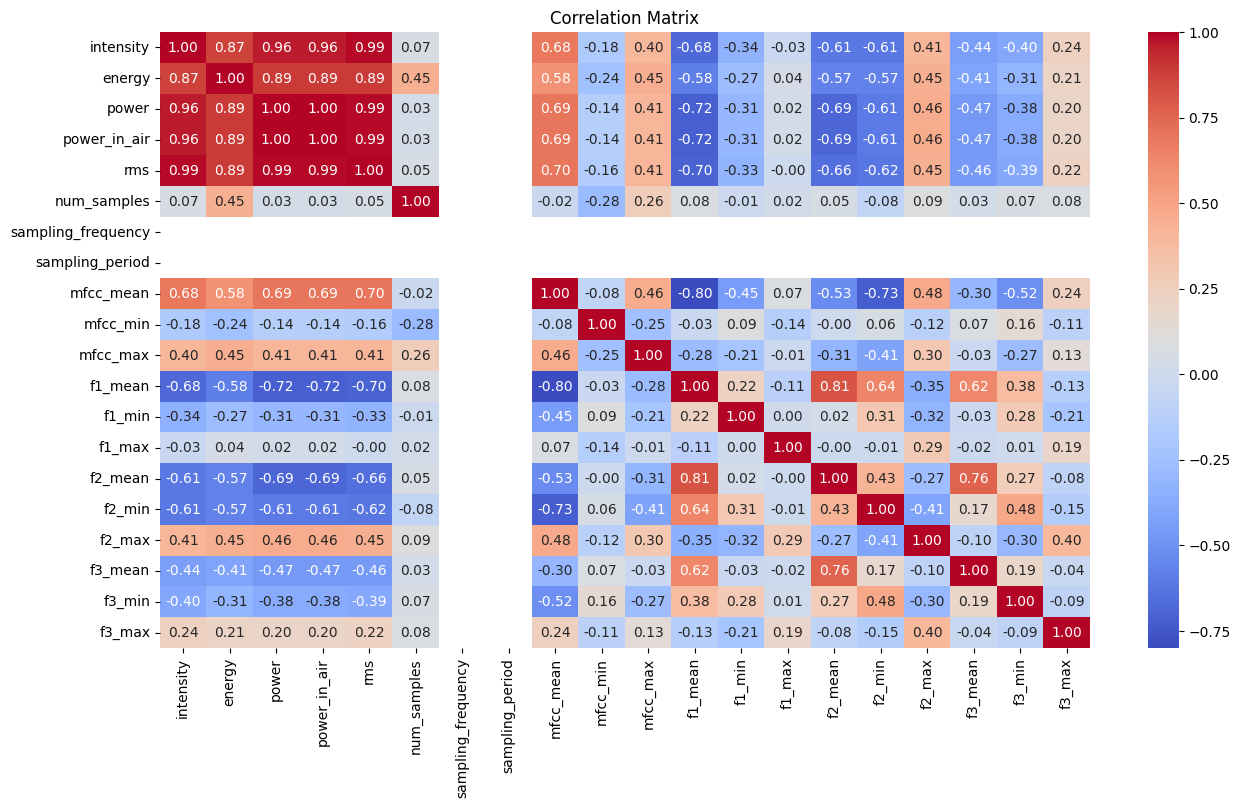

In [21]:
corr_matrix = df.drop(['speaker'], axis=1).corr()
plt.figure(figsize=(15, 8))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', cbar=True)

# Customize the plot for better readability
plt.title('Correlation Matrix')
plt.show()

In [23]:
# dropping highly correlated features - select only relevant features without too high or too low correlation + drop some wekaer ones to reduce COD
df_sel = df.copy()
df_sel = df_sel[['intensity', 'energy', 'num_samples', 'mfcc_mean', 'mfcc_min', 'mfcc_max', 'f1_mean', 'f2_mean', 'f3_mean', 'speaker']]

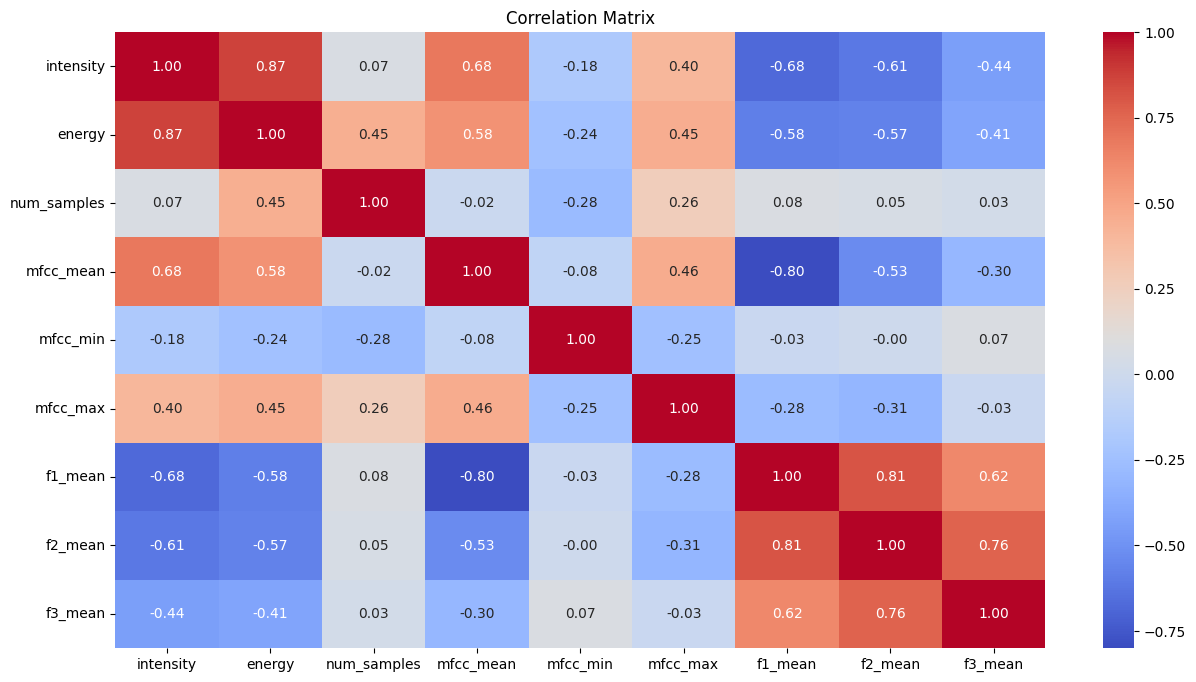

In [24]:
corr_matrix = df_sel.drop(['speaker'], axis=1).corr()
plt.figure(figsize=(15, 8))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', cbar=True)

# Customize the plot for better readability
plt.title('Correlation Matrix')
plt.show()

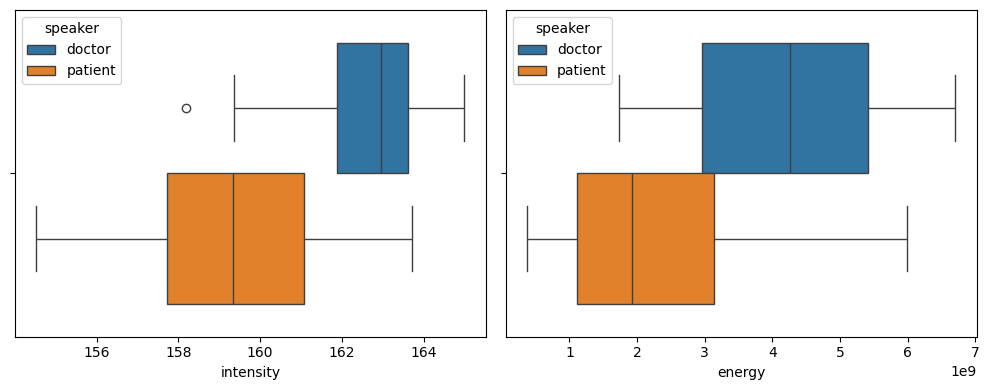

In [29]:
fig, axs = plt.subplots(1, 2, figsize=(10, 4))
sns.boxplot(data=df_sel, x = 'intensity', ax= axs[0], hue='speaker')
sns.boxplot(data=df_sel, x = 'energy', ax= axs[1], hue='speaker')
plt.tight_layout()
plt.show()

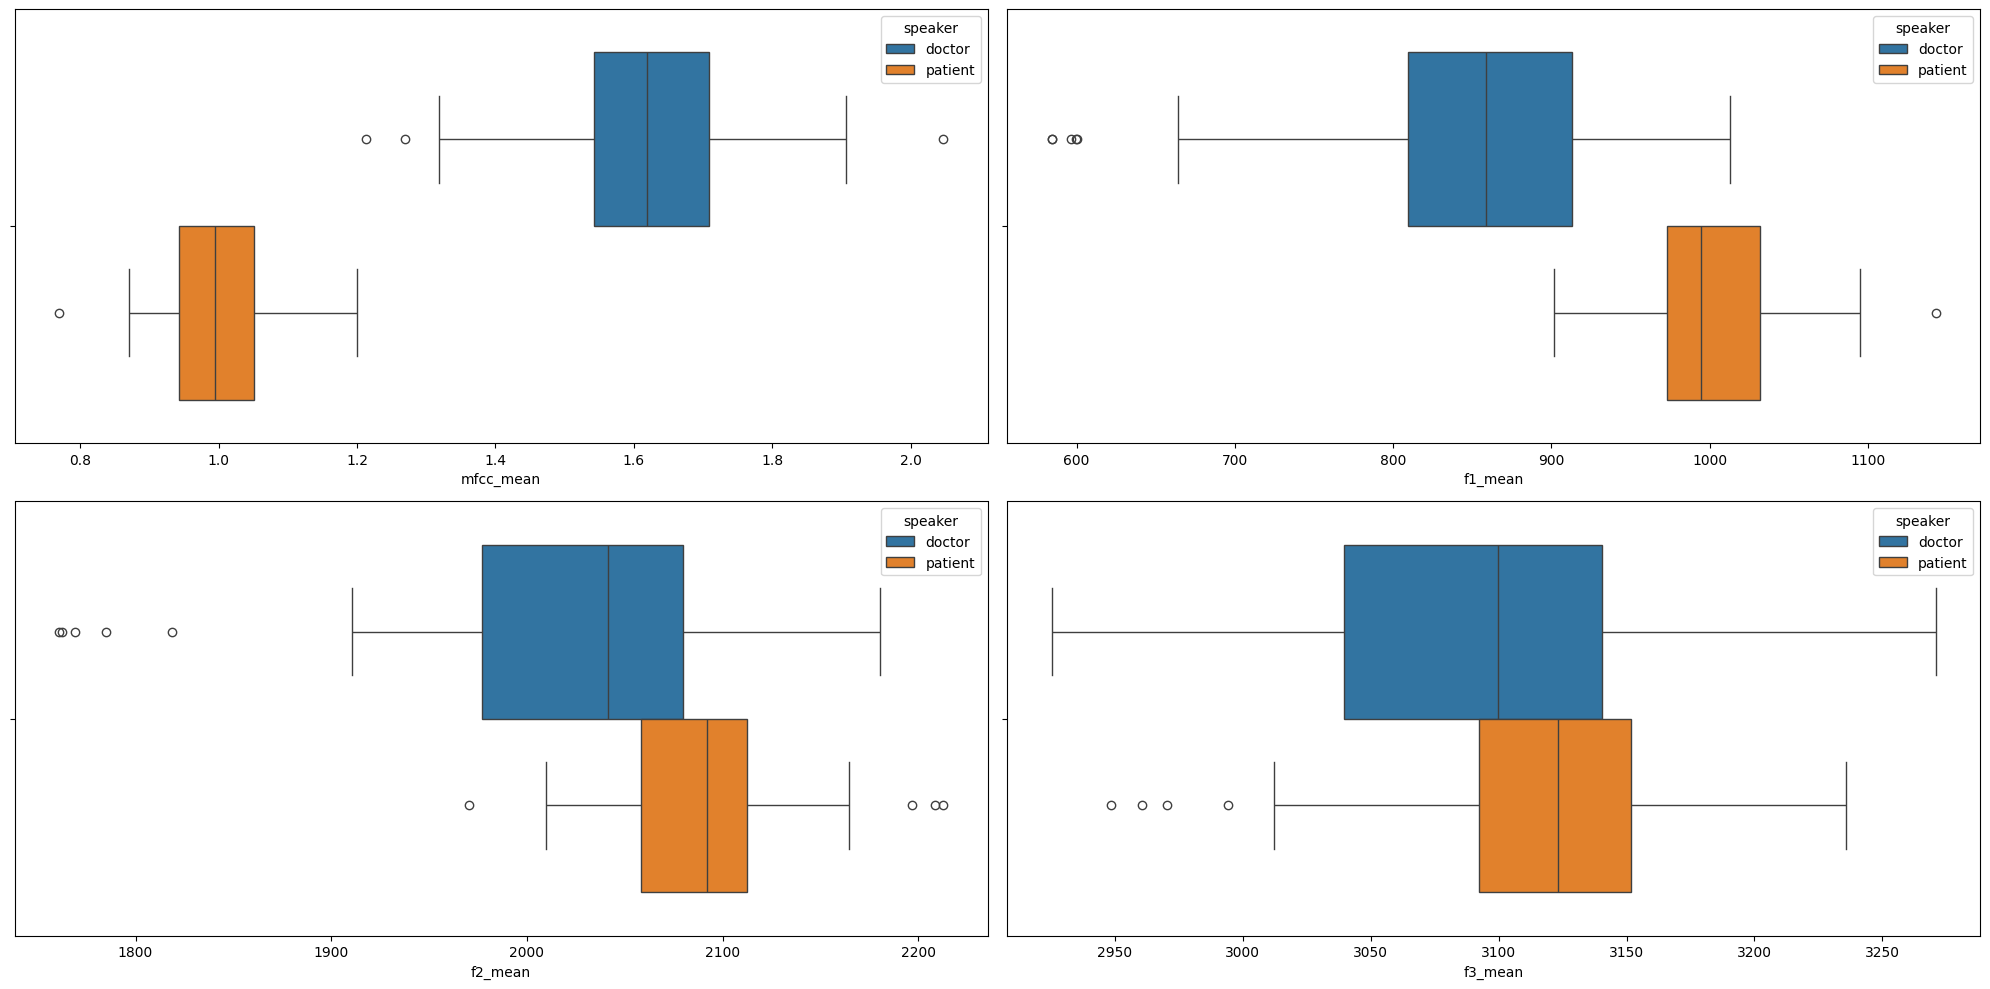

In [33]:
# 'mfcc_mean', 'f1_mean', 'f2_mean', 'f3_mean'
fig, axs = plt.subplots(2, 2, figsize=(20, 10))
sns.boxplot(data=df_sel, x = 'mfcc_mean', ax= axs[0][0], hue='speaker')
sns.boxplot(data=df_sel, x = 'f1_mean', ax= axs[0][1], hue='speaker')
sns.boxplot(data=df_sel, x = 'f2_mean', ax= axs[1][0], hue='speaker')
sns.boxplot(data=df_sel, x = 'f3_mean', ax= axs[1][1], hue='speaker')
plt.tight_layout()
plt.show()

In [36]:
# encode speaker: doctor = 1, patient = 0
df_sel['speaker'] = np.where(df_sel['speaker'] == 'doctor', 1, 0)
df_sel.head()

,intensity,energy,num_samples,mfcc_mean,mfcc_min,mfcc_max,f1_mean,f2_mean,f3_mean,speaker
0,164.2531,4.877127e+09,7326720,1.6599,-25.8373,30.9065,865.5993,1942.2548,3099.8796,1
1,162.5111,3.265118e+09,7325760,1.1144,-21.6133,28.4484,947.1340,2067.5670,3168.7352,0
2,163.4221,4.918549e+09,8947200,1.3802,-27.8706,26.5344,787.5786,1965.0772,3136.2059,1
3,162.9045,4.365905e+09,8947200,1.0382,-23.1743,27.6165,961.1078,2065.3357,3085.1000,0
4,164.2211,5.754769e+09,8709120,1.8327,-25.9320,32.8032,878.8603,1977.2152,3140.4732,1


In [43]:
# modelling
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score


X = df_sel.drop(columns=['speaker']) 
y = df_sel['speaker']  

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)


y_pred = rf.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
report = classification_report(y_test, y_pred)

print(f"Accuracy: {accuracy}")
print("Classification Report:")
print(report)

Accuracy: 1.0
Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         9
           1       1.00      1.00      1.00        14

    accuracy                           1.00        23
   macro avg       1.00      1.00      1.00        23
weighted avg       1.00      1.00      1.00        23



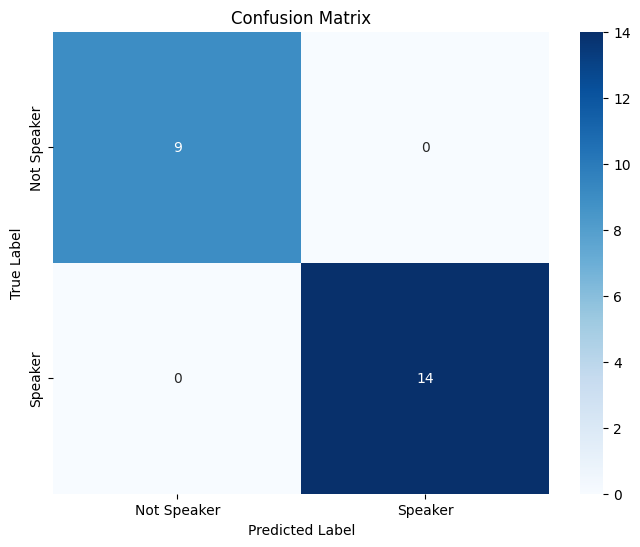

In [44]:
from sklearn.metrics import confusion_matrix

# Generate the confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Create a heatmap to visualize the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Not Speaker', 'Speaker'], yticklabels=['Not Speaker', 'Speaker'])
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()